# GSoC 2026: RenAIssance - Test (Handwritten Text Recognition)

In [29]:
!pip install -q transformers torch pillow jiwer opencv-python-headless

In [30]:
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image
from jiwer import cer, wer

# 1. Load the Processor and Model
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten')

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Handwriting Model loaded on: {device}")

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Handwriting Model loaded on: cuda


In [31]:
import cv2
import numpy as np
from PIL import Image

def preprocess(image_path):
    # Load in grayscale
    img = cv2.imread(image_path, 0)

    # Denoising to handle ink-bleed and paper grain
    denoised = cv2.fastNlMeansDenoising(img, None, 10, 7, 21)

    # Adaptive Thresholding (Sauvola-like logic) to pop the ink from the background
    # This is critical for 17th-century faded ink
    processed = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                      cv2.THRESH_BINARY, 11, 2)

    cv2.imwrite("enhanced_input.jpg", processed)
    return "enhanced_input.jpg"


In [32]:
def process_manuscript(img_path):
    # Image preprocessing for better contrast (VLM logic)
    image = Image.open(img_path).convert("RGB")

    # Preprocessing features for the Transformer
    pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

    # Autoregressive generation (The VLM part)
    generated_ids = model.generate(pixel_values)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return generated_text

# Run pipeline
preprocessed_path = preprocess("/content/handwriting_test.jpg")

image_path = preprocessed_path
raw_transcription = process_manuscript(image_path)

print("-" * 30)
print("EXTRACTED TEXT FROM MANUSCRIPT:")
print("-" * 30)
print(raw_transcription)

------------------------------
EXTRACTED TEXT FROM MANUSCRIPT:
------------------------------
of 1 -


In [39]:
# Word file
ground_truth = """ Elena de aguirre Vesina desta Villa de Oñate madre legitima de maria

Andres de arregui mi Hija legitima y de martin de arregui mi marido resi-

dente muchos años ha enlas yndias conla Venia que a V. m. pido en

falta dela marital y siendome concedida para lo que Dire de yuso pa-

resco ante V. m. por la mejor forma que Hubiere lugar de derecho y

premiso lo necesario acuso criminal mente a santiago de gardeagoitia lan-

daberde, clerigo Presuitero y natural de aRigorriaga en el señorio de Vis-

caya y Haciendo Verdadera relacion de mi querella, es ansi que como es

notorio y por tal alego que Teniendo yo ala dHa mari andres mi hija

doncella en cauillo en mi casa y campania en esta dHa Villa con mucha

onestidad y Recogimiento De Hedad de diez y nueve años poco mas

o menos el dHo acusado siendo estudiante matriculado en esta Uniuer-

sidad y ordenado De orden sacra postponiendo el Temor de Dios y de su

Conciencia y en gran perjuizio de mi onrra y reputacion y dela dHa mi

Hija abra tres años poco mas o menos de baxo de muchos ofrecimi-

entos y palabras la reduxo a su gusto y Voluntad y la hizo per-

der su linpieza y onestidad y sacandola por fuerça y contra mi vo-

luntad delas dHas mis casas la lleuo al dHo Lugar de aRigorria-

ga, donde la Ha tenido siempre y la tiene al presente en lo que

cometiò muy atroces delictos dignos de exemplar punicion y cas-

tigo e yncurrio en muchas penas establecidas por derecho comun-

leies de estos reynos = Por tanto pido y supp.co a V. m. auida Por ver

dadera y notoria esta mi Relacion declare al dHo santiago de gar-

deagoitia por perpetrador de los dHos delictos y le condene y execute

en su persona y bienes las dHas penas y las mayores que en este ca

so lugar Hubiere e ynçidentemente y de su oficio condene al dHo

santiago a que de y pague por docte de la dHa mari andres quinien-

tos ducados los quales y muchos mas tenia y esperaua tener al tpo

que con el se encontro de sus legitimas paterna y materna y de las pi-

as memorias que en esta dHa Villa dexaron martin y bbañes de heind..."""

# Calculate Metrics
error_rate = cer(ground_truth, raw_transcription)
word_error = wer(ground_truth, raw_transcription)

print(f"Character Error Rate (CER): {error_rate:.2%}")
print(f"Word Error Rate (WER): {word_error:.2%}")

Character Error Rate (CER): 99.76%
Word Error Rate (WER): 100.00%


In [34]:
# Testing on different handwritten sources to identify script-specific failure points
test_images = ["/content/handwriting_test.jpg", "/content/handwriting_test_2.jpg", "/content/handwriting_test_3.jpg"]

print("Cross-Source HTR Evaluation:")
for img_path in test_images:
    try:
        enhanced = preprocess(img_path)
        output = process_manuscript(enhanced)
        print(f"\nSource: {img_path.split('/')[-1]}")
        print(f"Output: {output if output else '[No Text Detected]'}")
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

Cross-Source HTR Evaluation:

Source: handwriting_test.jpg
Output: of 1 -

Source: handwriting_test_2.jpg
Output: First appearance between the first appearance was the first appearance of the first appearance in the first appearance

Source: handwriting_test_3.jpg
Output: a b c d e f g h.


Analyzing Document Structure for Marginalia Filtering...


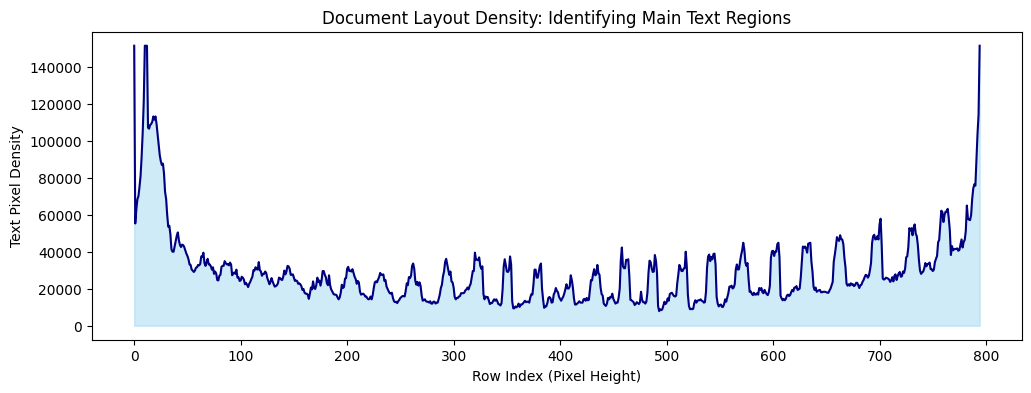

In [38]:
import matplotlib.pyplot as plt

def plot_layout_logic(image_path):
    # Using horizontal projection to identify main text blocks vs marginalia
    img = cv2.imread(image_path, 0)
    binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

    # Summing pixels horizontally
    hp_profile = np.sum(binary, axis=1)

    plt.figure(figsize=(12, 4))
    plt.plot(hp_profile, color='navy')
    plt.fill_between(range(len(hp_profile)), hp_profile, color='skyblue', alpha=0.4)
    plt.title("Document Layout Density: Identifying Main Text Regions")
    plt.xlabel("Row Index (Pixel Height)")
    plt.ylabel("Text Pixel Density")
    plt.show()

print("Analyzing Document Structure for Marginalia Filtering...")
plot_layout_logic("/content/handwriting_test_2.jpg")